All material needed for this notebook can be found in the public GitHub repository [https://github.com/dchoyle/datascience_notes](https://github.com/dchoyle/datascience_notes)

## Accuracy of trimmmed and MAD based estimates of the variance of a Normal distribution when a proportion of the data are outliers 

First we need to import the packages and functions we'll need

In [1]:
# First import the packages we need
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import norm, median_abs_deviation
from scipy.stats.mstats import trimmed_var

Next we'll create a pseudo-random-number generator (RNG) that we'll use to draw the samples of data for our simulations. We'll also set a matplotlib option to allow us to use LaTeX in our plot labels.

In [2]:
# Set options needed later
plt.rcParams['text.usetex'] = True
rng = np.random.default_rng(11386)

Now we can set up the simulations. We first define the parameters of the Normal distribution and then the simulation sizes we need. After that we'll pre-compute the correction constants that make our trimmed estimates of variance consistent with a Normal distribution.

In [3]:
# Set the parameters of the population from which we will draw the data
mu = 3.0
sigma = 2.1
true_var = np.power(sigma, 2.0)

## Parameters for the simuulation runs
n_sim = 1000
n_seq = [100, 200, 400, 800, 1600, 3200, 6400, 12800, 25600, 51200, 102400, 204800, 409600]
alpha_seq = [0.1, 0.2, 0.4]

## Pre-compute correction factors for each value of alpha
A_seq = []
for i in range(len(alpha_seq)):
    alpha = alpha_seq[i]
    x_alpha = norm.ppf(q=alpha*0.5, loc=0.0, scale=1.0) 
    A = x_alpha*norm.pdf(x=x_alpha, loc=0.0, scale=1.0)
    A *= 2.0/(1.0 - alpha)
    A += 1.0
    A_seq.append(A)

Now we'll run the simulations. This can take some time depending on the number of simulations we decided to run and also the largest sample sizes we've chosen to use. 

Note that we don't actually need to generate any outliers in our simulated data, since all we would do would be to discard them as part of the $\alpha$ fraction that we discard in calculating the trimmed variance. So in our simulations all our samples are just drawn from an ordinary Normal distribution.

In [4]:
## Run simulations
trim_var_estimates = np.zeros((len(n_seq), len(alpha_seq), n_sim))
mad_sd_estimates = np.zeros((len(n_seq), n_sim))
mad_var_estimates = np.zeros((len(n_seq), n_sim))
for i in range(len(n_seq)):
    n = n_seq[i]
    print("Running simulations for sample size N = " + str(n))
    for j in range(n_sim):
        s = rng.normal(mu, sigma, n)

        mad_sd_estimates[i, j] = median_abs_deviation(s, scale='normal')
        mad_var_estimates[i, j] = np.power(mad_sd_estimates[i, j], 2.0)


        for k in range(len(alpha_seq)):
            alpha = alpha_seq[k]
            trim_var_estimates[i, k, j] = \
            trimmed_var(s,
                        limits=(alpha*0.5, alpha*0.5),
                        inclusive=(1, 1),
                        relative=True,
                        axis=None,
                        ddof=1) / A_seq[k]

Running simulations for sample size N = 100
Running simulations for sample size N = 200
Running simulations for sample size N = 400
Running simulations for sample size N = 800
Running simulations for sample size N = 1600
Running simulations for sample size N = 3200
Running simulations for sample size N = 6400
Running simulations for sample size N = 12800
Running simulations for sample size N = 25600
Running simulations for sample size N = 51200
Running simulations for sample size N = 102400
Running simulations for sample size N = 204800
Running simulations for sample size N = 409600


Now we have trimmed and MAD based estimates of the population variance for all the sample datasets that we drew from that population, we can compute the mean and variance (over the simulation datasets) of those variance estimates. We'll also compute the standard errors of the means.

In [5]:
## Calculate the means,variances, and standard errors
# of the simulation estimates of the population variance
means_var_trimmed = np.mean(trim_var_estimates, axis=2)
means_sd_mad = np.mean(mad_sd_estimates, axis=1)
means_var_mad = np.mean(mad_var_estimates, axis=1)

vars_var_trimmed = np.var(trim_var_estimates, axis=2)
vars_sd_mad = np.var(mad_sd_estimates, axis=1)
vars_var_mad = np.var(mad_var_estimates, axis=1)

se_var_trimmed = np.sqrt(vars_var_trimmed/n_sim)
se_sd_mad = np.sqrt(vars_sd_mad/n_sim) 
se_var_mad = np.sqrt(vars_var_mad/n_sim) 

Now to plot the results. We'll start with the trimmed estimates of the population variance plotted against the log of the sample sizes (for the various different values of $\alpha$). We have chose to plot against $\log N$ simply to produce a neater graph, as our largest sample size is very big.

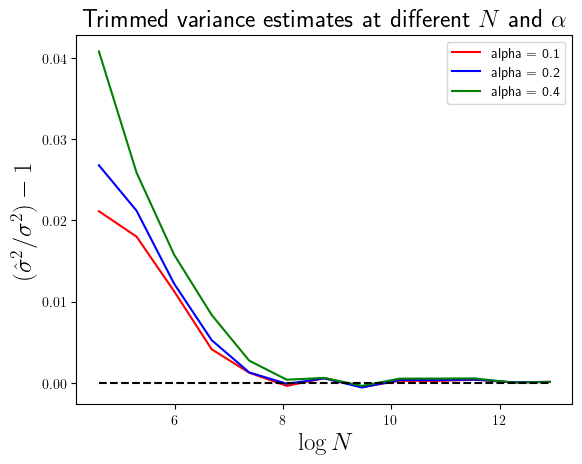

In [6]:
# Plot the Normal consistent trimmed estimates of the population
# variance against sample size
plt.plot(np.log(n_seq), (means_var_trimmed[:, 0]/true_var) - 1.0, 'red', label='alpha = ' + str(alpha_seq[0]))
plt.plot(np.log(n_seq), (means_var_trimmed[:, 1]/true_var) - 1.0, 'blue', label='alpha = ' + str(alpha_seq[1]))
plt.plot(np.log(n_seq), (means_var_trimmed[:, 2]/true_var) - 1.0, 'green', label='alpha = ' + str(alpha_seq[2]))

plt.hlines(y=0.0, xmin=np.log(n_seq[0]), xmax=np.log(n_seq[len(n_seq)-1]), colors='black', linestyles='dashed')
plt.xlabel(r'$\log N$', fontsize=18)
plt.ylabel(r'$(\hat{\sigma}^{2} /\sigma^{2}) - 1$', fontsize=18)
plt.title(r'Trimmed variance estimates at different $N$ and $\alpha$', fontsize=18)
plt.legend()
plt.show()

You can clearly see that the trimmed estimates of the true population variance are pretty good, even at the smaller sample sizes (about 2.5% to 3.5% error). At the larger sample sizes the accuracy is extremely good, suggesting that the trimmed variance estimator is a consistent one. 

At lower sample sizes you can see evidence of bias, with possibly the degree of bias being $\alpha$ dependent. To check this we'll need to make a better like-for-like comparison between the results for the different $\alpha$ values and also include the standard errors for those means over the simulation datasets. We'll only include the standard errors for one of the $\alpha$ series, as we expect the standard errors for the other $\alpha$ series to be similar in scale and otherwise the plot will get very crowded. The error bars we'll plot are actually $\pm$ 2 times the standard error.

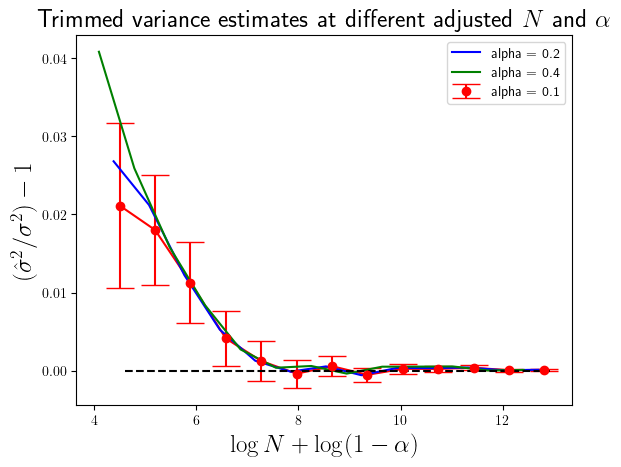

In [7]:
# Re-do the plot but against adjusted sample size, and also include
# the standard error estimates on one of the series
# variance against sample size
plt.errorbar(np.log(n_seq) + np.log(1.0 - alpha_seq[0]), 
             (means_var_trimmed[:, 0]/true_var) - 1.0,
             yerr=2.0*se_var_trimmed[:, 0]/true_var,
             xerr=None,
             color='red',
             label='alpha = ' + str(alpha_seq[0]),
             fmt='o',
             capsize = 10)

plt.plot(np.log(n_seq) + np.log(1.0 - alpha_seq[0]), (means_var_trimmed[:, 0]/true_var) - 1.0, 'red')
plt.plot(np.log(n_seq) + np.log(1.0 - alpha_seq[1]), (means_var_trimmed[:, 1]/true_var) - 1.0, 'blue', label='alpha = ' + str(alpha_seq[1]))
plt.plot(np.log(n_seq) + np.log(1.0 - alpha_seq[2]), (means_var_trimmed[:, 2]/true_var) - 1.0, 'green', label='alpha = ' + str(alpha_seq[2]))

plt.hlines(y=0.0, xmin=np.log(n_seq[0]), xmax=np.log(n_seq[len(n_seq)-1]), colors='black', linestyles='dashed')
plt.xlabel(r'$\log N + \log(1- \alpha)$', fontsize=18)
plt.ylabel(r'$(\hat{\sigma}^{2}/\sigma^{2}) - 1$', fontsize=18)
plt.title(r'Trimmed variance estimates at different adjusted $N$ and $\alpha$', fontsize=18)
plt.legend()
plt.show()

With the adjustment on the x-axis to the effective sample size, we can see that the simulation means for the three different $\alpha$ values are very similar, with the exception of the smallest sample sizes. Secondly, the inclusion of $\pm$ 2 standard error of the mean for the $\alpha = 0.1$ series, clearly shows the bias is real. If we had run more simulations, i.e. increased the n_sim simulation parameter, we could discerned the bias even for the larger values of $N$.

Next, we'll look at the performance of the Normal-consistent MAD-based estimate of the population standard deviation. We'll construct a similar plot as before, with the exception that there is only one series.

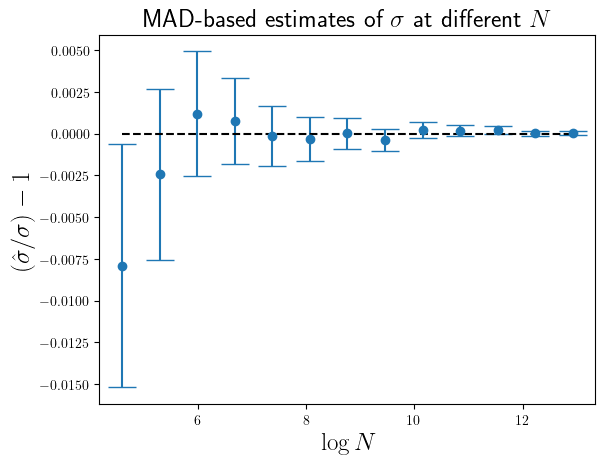

In [8]:
# Plot the Normal consistent MAD-based estimates of the population
# standard deviation against sample size
plt.errorbar(np.log(n_seq), 
             (means_sd_mad/sigma - 1.0),
             yerr=2.0*se_sd_mad/sigma,
             xerr=None,
             fmt='o',
             capsize = 10)

plt.hlines(y=0.0, xmin=np.log(n_seq[0]), xmax=np.log(n_seq[len(n_seq)-1]), colors='black', linestyles='dashed')
plt.xlabel(r'$\log N$', fontsize=18)
plt.ylabel(r'$\left( \hat{\sigma}/\sigma \right ) - 1$', fontsize=18)
plt.title(r'MAD-based estimates of $\sigma$ at different $N$', fontsize=18)
plt.show()

The points are the simulation means, whilst the error bars are $\pm$ 2 standard errors of the mean (estimated from the variance over the simulation results). We can see that the accuarcy of the MAD-based estimate of $\sigma$ is very good. This would appear (from the plot) to be a consistent estimator. Again we can see evidence of the bias in the estimator at the smaller values of $N$.

However, we can't do a comparison with the trimmed-variance estimator, as we are estimating a different quantity. The trimmed-variance estimates the underlying population variance, whilst the MAD-based estimator estimates the underlying population standard deviation. Fortunately, when we were computing the MAD-based estimates, we also stored the effective estimates of the variance, so we can do a like-for-like comparison with the trimmed-variance estimator. This is shown in the plot below. 

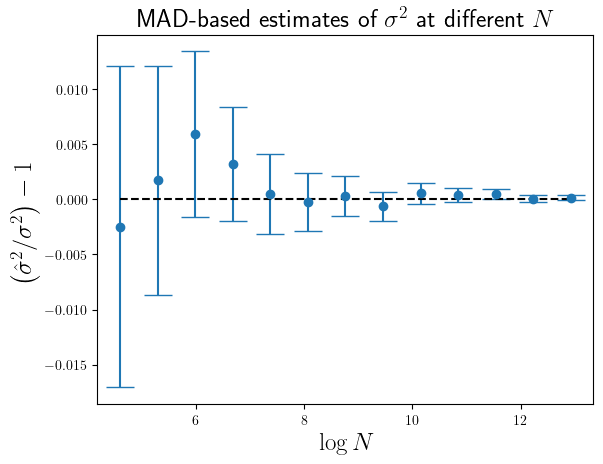

In [9]:
# Plot the Normal consistent MAD-based estimates of the population
# variance against sample size
plt.errorbar(np.log(n_seq), 
             ((means_var_mad/true_var) - 1.0),
             yerr=2.0*se_var_mad/true_var,
             xerr=None,
             fmt='o',
             capsize = 10)

plt.hlines(y=0.0, xmin=np.log(n_seq[0]), xmax=np.log(n_seq[len(n_seq)-1]), colors='black', linestyles='dashed')
plt.xlabel(r'$\log N$', fontsize=18)
plt.ylabel(r'$\left( \hat{\sigma}^{2}/\sigma^{2} \right ) - 1$', fontsize=18)
plt.title(r'MAD-based estimates of $\sigma^{2}$ at different $N$', fontsize=18)
plt.show()

The accuarcy of the MAD-based estimator appears to be, at least for these simulation results, superior to the trimmed-variance estimator, with the errors being around $\pm 1$%. The number of simulation runs n_sim is not sufficient in these set of results to properly detect the bias even for the smallest values of $N$. However, given the previous plot, we would expect that if we increased n_sim appropriately, we would be able to resolve this, i.e. it is simply that the standard errors of the mean of $\hat{\sigma}^{2}/\sigma^{2}$ are larger than the standard errors of the mean of $\hat{\sigma}/\sigma$ (for this MAD-based estimator).